In [ ]:
import pandas as pd

df =  pd.read_csv("/Users/connormackey/Downloads/shot_logs.csv")

df.head()

In [ ]:
# Allows us to see columns and number of rows in the dataframe. 
print("rows", "columns:", df.shape)

rows columns: (128069, 21)


In [ ]:
#Lets check what each row looks like. Enter a value in the bracket
#if you would like to see more than just the first 5 rows.
df.head(20)

In [ ]:
#What type is each column ? df.info, will allow us to check which columns contain missing valiues. 
df.info()
#We can see by the output that shot clock has only 122502 values, while it should have 128069. 
#This indicated there are missing value in the shot clock column. 
# This command also shows the type of data in each columns, int64 just an integer, 
# float 64 is a decimal number, and object is a string, (e.g shot made or missed), we will have 
# to change shot made or missed to a binary outcome? 1 made or 0 missed. 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128069 entries, 0 to 128068
Data columns (total 21 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   GAME_ID                     128069 non-null  int64  
 1   MATCHUP                     128069 non-null  object 
 2   LOCATION                    128069 non-null  object 
 3   W                           128069 non-null  object 
 4   FINAL_MARGIN                128069 non-null  int64  
 5   SHOT_NUMBER                 128069 non-null  int64  
 6   PERIOD                      128069 non-null  int64  
 7   GAME_CLOCK                  128069 non-null  object 
 8   SHOT_CLOCK                  122502 non-null  float64
 9   DRIBBLES                    128069 non-null  int64  
 10  TOUCH_TIME                  128069 non-null  float64
 11  SHOT_DIST                   128069 non-null  float64
 12  PTS_TYPE                    128069 non-null  int64  
 13  SHOT_RESULT   

In [ ]:
#Lets check what is missing in each data set. 
missing = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(1),
})
# Sort so the columns needing the most attention appear first.
missing.sort_values("n_missing", ascending=False)
#Is there a pattern to the missing data? PCT = Percentage

,n_missing,pct_missing
SHOT_CLOCK,5567,4.3
GAME_ID,0,0.0
SHOT_DIST,0,0.0
player_name,0,0.0
PTS,0,0.0
FGM,0,0.0
CLOSE_DEF_DIST,0,0.0
CLOSEST_DEFENDER_PLAYER_ID,0,0.0
CLOSEST_DEFENDER,0,0.0
SHOT_RESULT,0,0.0


In [ ]:
##Lets Analyse duplicate values.
# We do not have a single duplicate row in the data set which is primising from a data cleaning perspective. 
print("exact duplicate rows:", df.duplicated().sum())

exact duplicate rows: 0


In [ ]:
#This function will give us the descriptive statistics for each variable.
# I have Identified some concerning issue, 
df.describe().T
# The minimum touch time is negative, it is not possible to have negative touches. 
# This is worrying and will have to be investigated later on during the data cleaning process.
#e^01 means to multiply by by 10, so as much to worry about as I initially thought. 

,count,mean,std,min,25%,50%,75%,max
GAME_ID,128069.0,2.140045e+07,257.877259,21400001.0,21400233.0,21400449.0,2.140067e+07,21400908.0
FINAL_MARGIN,128069.0,2.087234e-01,13.233267,-53.0,-8.0,1.0,9.000000e+00,53.0
SHOT_NUMBER,128069.0,6.506899e+00,4.713260,1.0,3.0,5.0,9.000000e+00,38.0
PERIOD,128069.0,2.469427e+00,1.139919,1.0,1.0,2.0,3.000000e+00,7.0
SHOT_CLOCK,122502.0,1.245334e+01,5.763265,0.0,8.2,12.3,1.667500e+01,24.0
DRIBBLES,128069.0,2.023355e+00,3.477760,0.0,0.0,1.0,2.000000e+00,32.0
TOUCH_TIME,128069.0,2.765901e+00,3.043682,-163.6,0.9,1.6,3.700000e+00,24.9
SHOT_DIST,128069.0,1.357150e+01,8.888964,0.0,4.7,13.7,2.250000e+01,47.2
PTS_TYPE,128069.0,2.264670e+00,0.441159,2.0,2.0,2.0,3.000000e+00,3.0
CLOSEST_DEFENDER_PLAYER_ID,128069.0,1.590385e+05,78791.172947,708.0,101249.0,201949.0,2.030790e+05,530027.0


NameError: name 'plt' is not defined

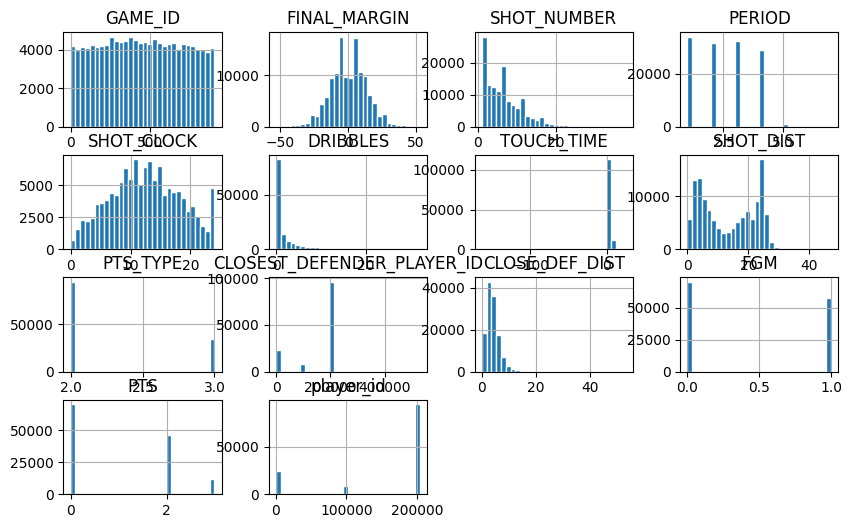

In [ ]:
df.select_dtypes("number").hist(figsize=(10, 6), bins=30, edgecolor="white")
plt.tight_layout()
plt.show()
# okay I have made some initial obervations that relate to our research question,
# that will require investiation. 
#Final Margin approached a normal distribution, but then exploded and dipped down, 
# This is strange, psychological element to winning margins ? 
#Shot clock almost a perfect normal distribution, suggesting that the majority of shots are taken 
# when the shot clock is around 12-14 seconds which is interesting. If teams opted to hold the ball 
#longer is there a greater chance they would make the shot ? 
# Shot distance is an extremely interesting graph, what it tells me is that players opt not 
# to shoot from just inside the three point line, as the graph dips down just inside the 
# the three point line, they opt to take a step back and shoot from the three point line. 

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

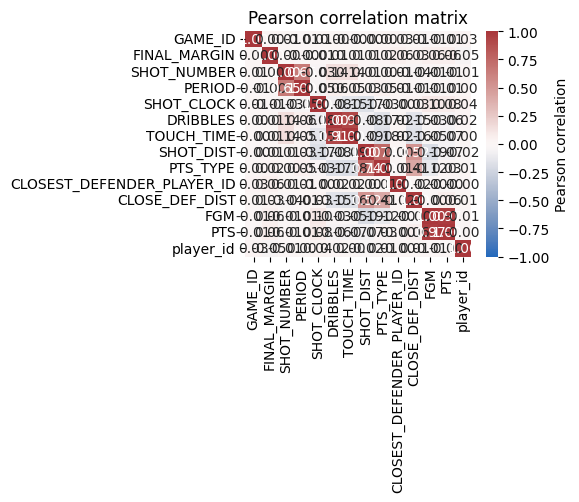

In [21]:
#Pearsons correlation co-efficient. 
# This is not running but not really surprising
numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

# A heatmap makes positive and negative relationships easier to scan.
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={"label": "Pearson correlation"})
plt.title("Pearson correlation matrix")
plt.tight_layout()
plt.show()

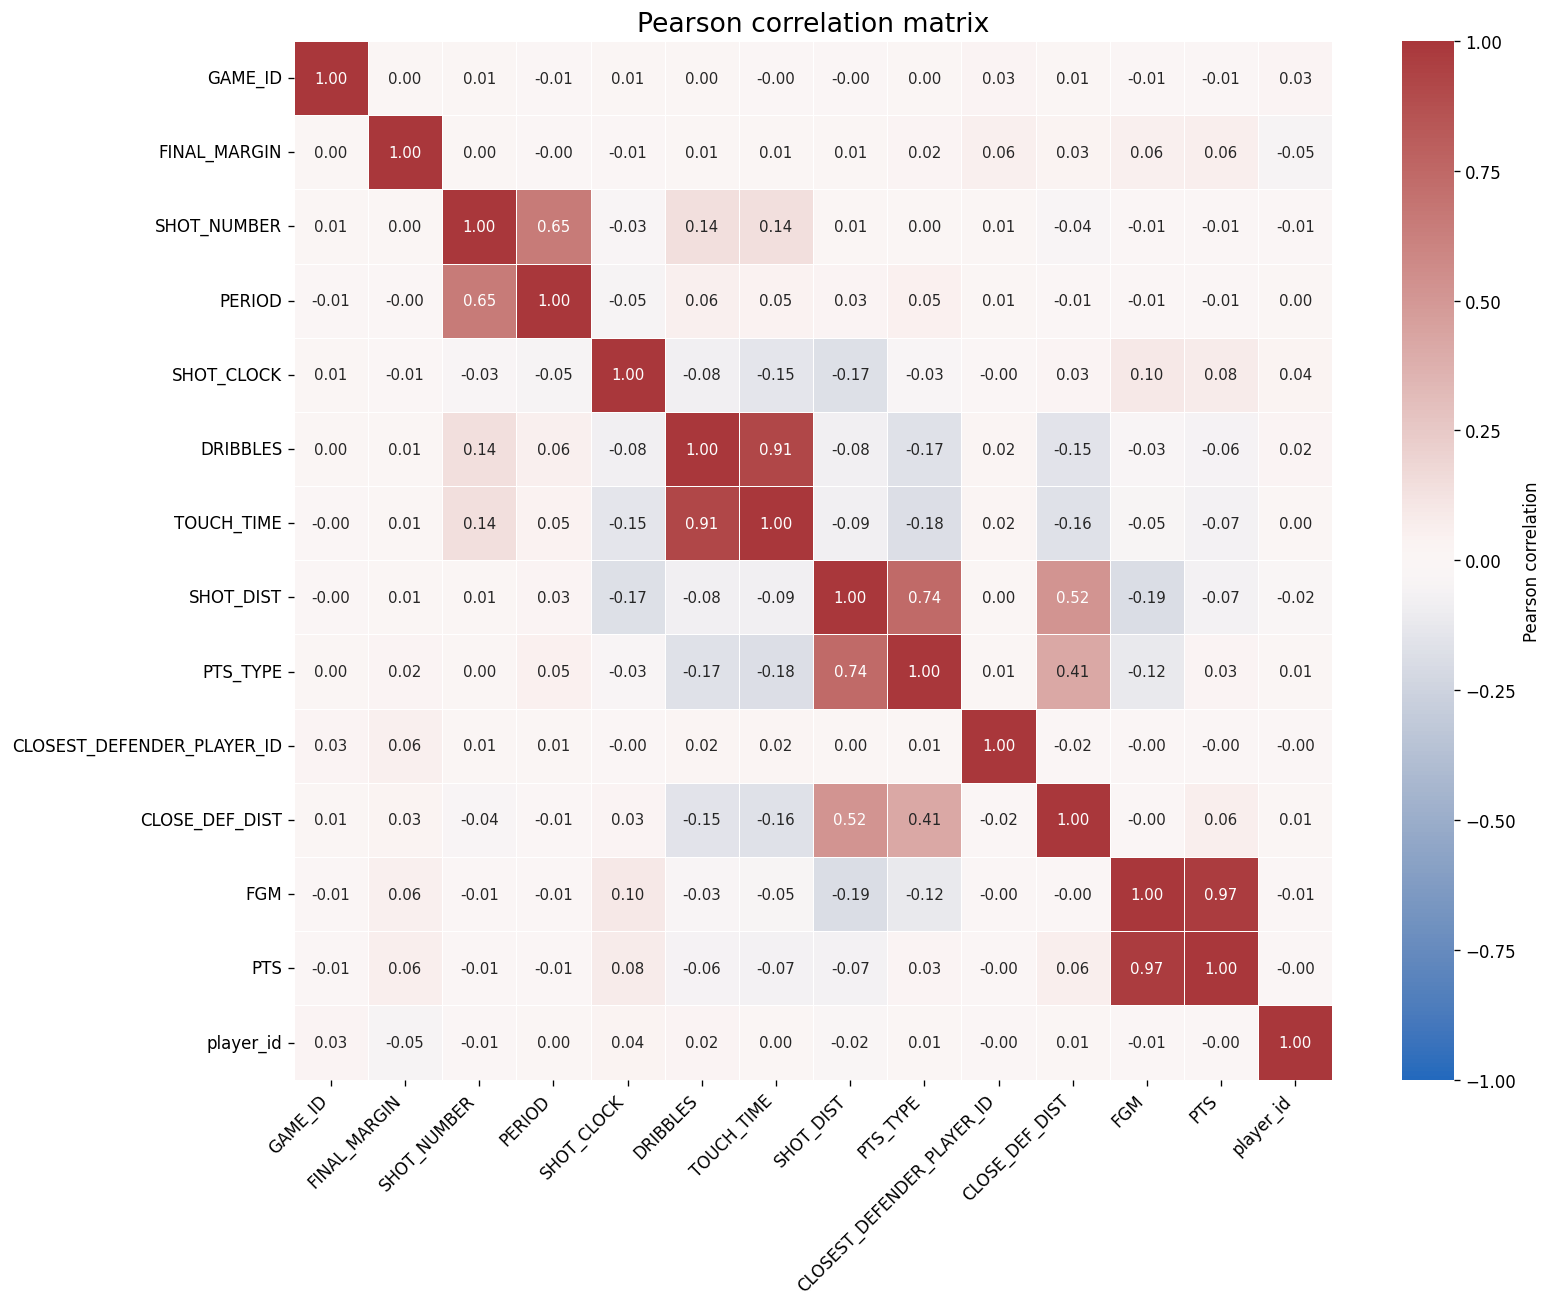

In [23]:
## Using different code as I cannot view the values in heat map as there are to manu variables. 
import matplotlib.pyplot as plt
import seaborn as sns

numeric_data = df.select_dtypes("number")
corr = numeric_data.corr(method="pearson")

plt.figure(figsize=(14, 11), dpi=120)

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Pearson correlation"}
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.title("Pearson correlation matrix", fontsize=16)
plt.tight_layout()
plt.show()

---
## Your turn

Take a few minutes to inspect this dataset. Write three short observations:

1. **One thing that surprised you**
2. **One thing that looks potentially wrong or worth checking**
3. **One question you would investigate next**

The aim is not to “solve” the dataset. Good exploratory analysis produces better questions.

In [ ]:

# What surpsied me : 
# The data set is relatively clean there is not to many missing values. 
#  The plots told a story, players make a decision whether deliberatley or not to avoid, 
# shooting from just inside the three point line, as it is 2 pts from almost the same distance. 
# Final margins did not follow a normal distribution which is unusual. 
## One thing that looks potentially wrong or worth checkling :
# The touch time is negative, which is not possible, this will have to be investigated further. 
## One question I would investigate further. 
# Genuinely all of the above, it is essential to establish why touch time is negative, this could be one 
# mis-entry, however before any analysis can begin this will have to be established. 
# I am also extremelty interested to know if this conscious decision from player to not shoot,
# from just inside the three point line actually offers better outcomes. 